In [2]:
print("Everything is fine")

Everything is fine


In [3]:
# import the required libraries

import os

from dotenv import load_dotenv

load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

### Create vector store for langchain and Langgraph documents

In [4]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS

import warnings
warnings.filterwarnings("ignore")

d:\GENAIBatch\langchain_new\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [5]:
urls = [
    "https://docs.langchain.com/oss/python/langgraph/overview",
    "https://docs.langchain.com/oss/python/langgraph/workflows-agents",
    "https://docs.langchain.com/oss/python/langgraph/studio",
    "https://docs.langchain.com/oss/python/langchain/tools",
    "https://cloud.google.com/discover/what-are-ai-agents"]

docs = [WebBaseLoader(url).load() for url in urls]
docs

[[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph overview - Docs by LangChainSkip to main contentJoin us May 13th & May 14th at Interrupt, the Agent Conference by LangChain. Buy tickets >Docs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceDurable executionStreamingInterruptsTime travelMemorySubgraphsProductionApplication structureTestLangSmith StudioAgent Chat UILangSmith DeploymentLangSmith ObservabilityFrontendOverviewGraph executionLangGraph APIsGraph APIFunctional APIRuntimeOn this page InstallC

In [6]:
doc_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=100)

doc_splits = text_splitter.split_documents(doc_list)

print(doc_list)

print(("^"*25))

print(doc_splits)

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph overview - Docs by LangChainSkip to main contentJoin us May 13th & May 14th at Interrupt, the Agent Conference by LangChain. Buy tickets >Docs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceDurable executionStreamingInterruptsTime travelMemorySubgraphsProductionApplication structureTestLangSmith StudioAgent Chat UILangSmith DeploymentLangSmith ObservabilityFrontendOverviewGraph executionLangGraph APIsGraph APIFunctional APIRuntimeOn this page InstallCo

In [7]:
# Add all this to vector database

vectorstore = FAISS.from_documents(
    documents = doc_splits,
    embedding = OpenAIEmbeddings(model="text-embedding-3-large") #1024 dimensions
)

retriever = vectorstore.as_retriever()

In [8]:
# testing the vector store

retriever.invoke("What is langgraph?")

[Document(id='af1bdd0c-d1e2-481a-b9fe-7526b0e71711', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='\u200bLangGraph ecosystem\nWhile LangGraph can be used standalone, it also integrates seamlessly with any LangChain product, giving developers a full suite of tools for building agents. To improve your LLM application development, pair LangGraph with:'),
 Document(id='7d50fc2f-7374-46fa-93df-407eaf89cc5b', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph is very low-level, and focused entirely on agent orchestration. Before using LangGraph, we recommend you 

In [9]:
# Retriever to Retriever tools

from langchain_core.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(
    retriever,
    "retriever_vector_db_blogs",
    "Search and run information about langgraph"
)

In [10]:
retriever_tool

StructuredTool(name='retriever_vector_db_blogs', description='Search and run information about langgraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x000001FF40F5BEC0>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x000001FF42B52B60>)

In [11]:
# Create similar type of database for langchain

langchain_urls = [
    "https://docs.langchain.com/oss/python/langchain/overview",
    "https://docs.langchain.com/oss/python/langchain/agents",
    "https://docs.langchain.com/oss/python/langchain/mcp",
    "https://docs.langchain.com/oss/python/langchain/human-in-the-loop",
    "https://docs.langchain.com/oss/python/langchain/multi-agent/router"
]

langchain_docs = [WebBaseLoader(url).load() for url in langchain_urls]
langchain_docs

[[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain is an open source framework with a prebuilt agent architecture and integrations for any model or tool—so you can build agents that adapt as fast as the ecosystem evolves', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainSkip to main contentJoin us May 13th & May 14th at Interrupt, the Agent Conference by LangChain. Buy tickets >Docs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareFrontendOverviewPatternsIntegrationsAdvanced usageGuardrailsRuntimeContext engineeringModel 

In [12]:
langchain_doc_list = [item for sublist in langchain_docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=100)

langchain_doc_splits = text_splitter.split_documents(langchain_doc_list)

print(langchain_doc_list)

print(("^"*25))
print(langchain_doc_splits)

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain is an open source framework with a prebuilt agent architecture and integrations for any model or tool—so you can build agents that adapt as fast as the ecosystem evolves', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainSkip to main contentJoin us May 13th & May 14th at Interrupt, the Agent Conference by LangChain. Buy tickets >Docs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareFrontendOverviewPatternsIntegrationsAdvanced usageGuardrailsRuntimeContext engineeringModel C

In [13]:
# Add all this to vector database

vectorstore_langchain = FAISS.from_documents(
    documents = langchain_doc_splits,
    embedding = OpenAIEmbeddings()
)

retriever_langchain = vectorstore_langchain.as_retriever()

In [14]:
# testing the vector store

retriever_langchain.invoke("What is contect engineering?")

[Document(id='7128847c-b71c-4f9c-a144-442468dcbe8e', metadata={'source': 'https://docs.langchain.com/oss/python/langchain/agents', 'title': 'Agents - Docs by LangChain', 'language': 'en'}, page_content='developmentLangSmith StudioTestAgent Chat UIDeploy with LangSmithDeploymentObservabilityOn this pageCore componentsModelStatic modelDynamic modelToolsStatic toolsDynamic toolsTool error handlingTool use in the ReAct loopSystem promptDynamic system promptNameInvocationAdvanced conceptsStructured outputToolStrategyProviderStrategyMemoryDefining state via middlewareDefining state via state_schemaStreamingMiddlewareCore componentsAgentsCopy pageCopy pageAgents combine language models with tools to create systems that can reason about tasks, decide which tools to use, and iteratively work towards solutions.'),
 Document(id='41ccc6fc-7658-4e71-9154-65e4d8681db2', metadata={'source': 'https://docs.langchain.com/oss/python/langchain/mcp', 'title': 'Model Context Protocol (MCP) - Docs by LangCha

In [15]:
# Retriever to Retriever tools

from langchain_core.tools.retriever import create_retriever_tool

langchain_retriever_tool = create_retriever_tool(
    retriever_langchain,
    "retriver_vector_db_langchain",
    "Search and run information about langchain"
)

In [16]:
langchain_retriever_tool

StructuredTool(name='retriver_vector_db_langchain', description='Search and run information about langchain', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x000001FF47315C60>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x000001FF47315E40>)

In [17]:
tools = [retriever_tool, langchain_retriever_tool]

### Langgraph Workflow

In [18]:
# STEP : Define the State

from typing_extensions import TypedDict
from typing import Annotated, Sequence
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):

    # The add_messages function defines how messages are combined
    # Default is replace , add_messages appends messages
    # BaseMessage is the base class for all messages in langgraph, it can be used to define custom message types
    # Since we are using add_messages, the messages will be appended to the existing messages in the state, instead of replacing them
    # Sequence is a generic type that represents a sequence of items, in this case, a sequence of BaseMessage objects
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [19]:
 # STEP : Define the LLM

from langchain_groq import ChatGroq

llm = ChatGroq(model = "qwen/qwen3-32b")

llm.invoke("Hello, how are you?")

AIMessage(content="<think>\nOkay, the user sent a greeting and a question. I need to respond in a friendly and warm manner. First, I should thank them for their greeting and then ask how I can assist them. The user might want to chat or have specific questions, so I should keep the response open-ended to encourage further communication. I need to ensure the tone is natural, not too formal, and shows a positive attitude. Let me structure the response into two parts: first acknowledging their greeting, then expressing willingness to help. I'll avoid any technical jargon and keep it simple and conversational.\n</think>\n\nHello! I'm doing great, thanks for asking. How can I assist you today? 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 143, 'prompt_tokens': 14, 'total_tokens': 157, 'completion_time': 0.329253161, 'completion_tokens_details': None, 'prompt_time': 0.000617982, 'prompt_tokens_details': None, 'queue_time': 0.053469558, 'total_time': 0.3298

In [20]:
# STEP: Define the Agent

from langchain_groq.chat_models import ChatGroq
def agent(state):
    """
    Invoke the agent model to generate a response based on the current state. 
    
    Given the query, it will decide to retrieve using the retriever tool or simply end the conversation.

    Args:
        state: The current state of the conversation.

    Returns:
        state: The updated state of the conversation.
    """

    print("Calling Agent Model")

    messages = state["messages"]

    model = ChatGroq(model = "qwen/qwen3-32b")

    model = model.bind_tools(tools)

    response = model.invoke(messages)

    # We will return a list, because this will get added to the existing messages
    return {"messages": [response]}


In [21]:
# STEP: Grade the retrieved documents

# Load the libraries
from typing import Literal

from langchain_classic import hub
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate

from pydantic import BaseModel, Field

In [22]:
### Edges

def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("CHECK RELEVANCE")

    # Data model
    class grade(BaseModel):
        """Binary score for relevance check."""

        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM
    model = ChatGroq(model="qwen/qwen3-32b")

    # LLM with tool and validation
    llm_with_tool = model.with_structured_output(grade)

    # Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    # Chain
    chain = prompt | llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("DECISION: DOCS RELEVANT")
        return "generate"

    else:
        print("DECISION: DOCS NOT RELEVANT")
        print(score)
        return "rewrite"

In [23]:
# STEP : Define the generate function

def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("GENERATE")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt - Pull the RAG prompt from the hub
    prompt = hub.pull("rlm/rag-prompt")

    # LLM - Use Groq as the LLM
    llm = ChatGroq(model="qwen/qwen3-32b")

    # Post-processing - Format the docs
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain - Combine the prompt, LLM and post-processing
    rag_chain = prompt | llm | StrOutputParser()

    # Run - Invoke the chain
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [24]:
# STEP : Define the rewrite function

def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("TRANSFORM QUERY")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    model = ChatGroq(model="qwen/qwen3-32b")
    response = model.invoke(msg)
    return {"messages": [response]}

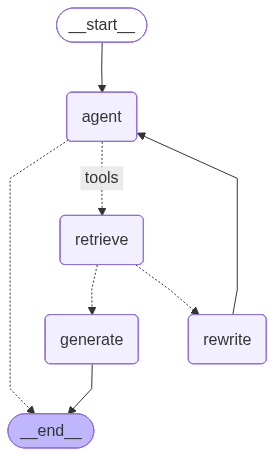

In [25]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode([retriever_tool,langchain_retriever_tool])
workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node( "generate", generate)  # Generating a response after we know the documents are relevant

# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
graph = workflow.compile()
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


In [26]:
graph.invoke({"messages":"What is LanggGraph?"})

Calling Agent Model
CHECK RELEVANCE
DECISION: DOCS RELEVANT
GENERATE


{'messages': [HumanMessage(content='What is LanggGraph?', additional_kwargs={}, response_metadata={}, id='debc3477-4dd0-4d76-911d-d87ec7be169b'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking, "What is LanggGraph?" First, I need to figure out which tool to use here. The available tools are retriever_vector_db_blogs for langgraph and retriver_vector_db_langchain for langchain. Since the user mentioned "LanggGraph," which seems similar to "LangGraph," I should check if that\'s a typo. Assuming it\'s a typo, the correct term might be LangGraph, which is part of the LangChain ecosystem. But the user could also be referring to a different tool. However, given the available functions, the best fit is the retriever_vector_db_blogs function, which is for searching information about langgraph. I\'ll use that to get the necessary information to answer the user\'s question.\n', 'tool_calls': [{'id': '4c8n3hy1q', 'function': {'arguments': '{"query":"What

In [30]:
graph.invoke({"messages":"What is Langchain?"})

Calling Agent Model
CHECK RELEVANCE
DECISION: DOCS RELEVANT
GENERATE


{'messages': [HumanMessage(content='What is Langchain?', additional_kwargs={}, response_metadata={}, id='e1237d8c-4bb7-4525-9e47-bcc291246033'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking, "What is Langchain?" I need to figure out which tool to use here. Let me check the available functions.\n\nLooking at the tools provided, there are two retrievers: one for langgraph and another for langchain. The user\'s query is specifically about Langchain, so the relevant function is retriver_vector_db_langchain. \n\nI should structure the query parameter to effectively search for information. The function requires a "query" argument. Since the user wants a definition or explanation of Langchain, the query should be something like "What is Langchain?" to retrieve the most relevant information.\n\nWait, the function name has a typo: "retriver" instead of "retriever". But the description says it\'s for Langchain, so that\'s the correct one. I\'ll procee

In [31]:
graph.invoke({"messages":"What is Machine Learning?"})

Calling Agent Model


{'messages': [HumanMessage(content='What is Machine Learning?', additional_kwargs={}, response_metadata={}, id='1d728012-bc22-4671-8829-38a493fda8d8'),
  AIMessage(content='The question "What is Machine Learning?" is a general conceptual inquiry and does not require specialized tools for langgraph or langchain. Here\'s a concise explanation:\n\n**Machine Learning (ML)** is a subset of artificial intelligence (AI) that focuses on developing algorithms and statistical models that enable computers to perform tasks without explicit instructions. Instead, these systems learn patterns and make decisions by analyzing large amounts of data. Key concepts include:\n\n1. **Supervised Learning**: Learning from labeled data (e.g., predicting house prices based on historical data).\n2. **Unsupervised Learning**: Finding hidden patterns in unlabeled data (e.g., clustering customers into segments).\n3. **Reinforcement Learning**: Training models through rewards/penalties in dynamic environments (e.g.,

In [32]:
graph.invoke({"messages":"What is Macine Leaning?"})

Calling Agent Model


{'messages': [HumanMessage(content='What is Macine Leaning?', additional_kwargs={}, response_metadata={}, id='35343463-abc7-4403-8529-7a28a7f46de6'),
  AIMessage(content='It seems there might be a typo in your query. If you\'re asking about **Machine Learning**, here\'s a brief explanation:\n\n**Machine Learning** is a subset of artificial intelligence (AI) that focuses on developing algorithms and models that enable computers to learn patterns from data, make predictions, or improve performance on tasks without being explicitly programmed. It includes techniques like supervised learning, unsupervised learning, and reinforcement learning.\n\nIf this isn\'t what you meant, please clarify! \n\n<note>  \nThe provided tools (retriever_vector_db_blogs and retriver_vector_db_langchain) are not applicable for defining general concepts like "Machine Learning." They are specific to searching information about "langgraph" or "langchain."  \n</note>', additional_kwargs={'reasoning_content': 'Okay

### Reflection or Conclusion
- With the help of this type of agentic workflow, you can develop any kind of use case where you need to combine the power of LLMs with the ability to access and process external data.
- Just one thing to note is that this is a very basic example of an agentic workflow. In a real-world scenario, you would need to add more complex logic to handle different types of external data and to handle different types of LLMs.
- In this example, we are using the OpenAI LLM and Groq LLM, but you can use any other LLM of your choice.
- There are various use cases where you can use this type of agentic workflow. Some of them are:
    - **Chatbots** - You can use this type of agentic workflow to build a chatbot that can answer questions and provide information to users.
    - **Customer Support** - You can use this type of agentic workflow to build a customer support system that can answer questions and provide information to users.
    - **Personal Assistant** - You can use this type of agentic workflow to build a personal assistant that can answer questions and provide information to users.
    - **Content Generation** - You can use this type of agentic workflow to build a content generation system that can generate content based on user input.
    - **Question Answering** - You can use this type of agentic workflow to build a question answering system that can answer questions and provide information to users.
    